# <center>Laboratorium 9<br>Metody Numeryczne</center>

Instrukcja:  
Na zajęciach należy wykonać poniższe zadania, a następnie sporządzić sprawozdanie zawierające odpowiedzi (w postaci kodu) z komentarzami w środowisku Jupyter Notebook i umieścić je na platformie e-learningowej.

***Materiały przygotowujące:***


In [7]:
import main
import numpy as np
import scipy as sp
from scipy import optimize
import matplotlib
import matplotlib.pyplot as plt
import math


***Temat główny:***

Znajdź miejsca zerowe funkcji: 
$
f(x) = e^{-2x} + x^2 - 1 
$

metodami:
* Bisekcji,
* Siecznych,
* Newtona

Funkcja i jej pochodne zostały zaimplementowane w *main.py*

***Zadanie 1.***  
Wykonaj wykres funckji oraz jej pierwszej i drugiej pochodnej (obliczonej analitycznie) na jednym rysunku w przedziale pozwalającym na zgrubne określenie miejsc zerowych. Wykres powinien być odpowiednio opisany. Określ przedział miejsca zerowego.

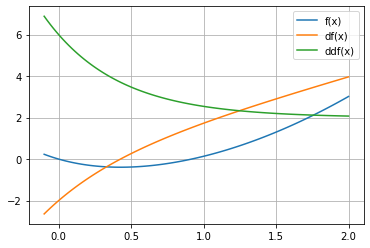

In [8]:
x=np.linspace(-0.1,2,100)
plt.plot(x,main.fun(x),label='f(x)')
plt.grid('k')
plt.plot(x,main.dfun(x),label='df(x)')
plt.plot(x,main.ddfun(x),label='ddf(x)')
plt.legend()

Przedział jest [0,1]

***Zadanie 2.***  
Zaimplementuj [metodę bisekcji](https://en.wikipedia.org/wiki/Bisection_method)

Gwarancja zbieżności:

1) funkcja jest ciągła na danym przedziale [a,b]

2) funkcja na końcach przedziału przyjmuje przeciwne znaki

***Zadanie 3.***  
Zaimplementuj [metodę siecznych](https://en.wikipedia.org/wiki/Secant_method)

Gwarancja zbieżności:

1) funkcja jest ciągła na danym przedziale [a,b]

2) Pierwsza i druga pochodna istnieją i są ciągłe w przedziale domkniętym [a,b]

3) funkcja na końcach przedziału przyjmuje przeciwne znaki

4) pierwsza i druga pochodna mają stały znak (brak eksremów lokalnych i punktów przegięcia)


***Zadanie 4.***  
Zaimplementuj [metodę Newtona](https://en.wikipedia.org/wiki/Newton%27s_method)

Gwarancja zbieżności:

1) funkcja jest ciągła na danym przedziale [a,b]

2) Pierwsza i druga pochodna istnieją i są ciągłe w przedziale domkniętym [a,b]

3) funkcja na końcach przedziału przyjmuje przeciwne znaki

4) pierwsza i druga pochodna mają stały znak (brak eksremów lokalnych i punktów przegięcia)


***Zadania 5.***  
Dla głównej funkcji z zadania 1 znajdź miejsca zerowe przy użyciu:

* funkcji root dostępnej w pakiecie scipy.optimize
* funkcji fsolve dostępnej w pakiecie scipy.optimize


In [9]:
f1=sp.optimize.root(main.fun,[0,1])
f2=sp.optimize.fsolve(main.fun,[0,1])
print("dla root fun jest tam ",f1.x," bliskie ",np.isclose(main.fun(f1.x), [0, 0])," zeru")
print("dla fsolve fun jest tam ",f2," bliskie ",np.isclose(main.fun(f2), [0, 0])," zeru")

dla root fun jest tam  [0.         0.91656258]  bliskie  [ True  True]  zeru
dla fsolve fun jest tam  [0.         0.91656258]  bliskie  [ True  True]  zeru


***Zadanie 6.***  
Dla głównej funkcji oraz przedziału zdefiniowanego z zadania 1 znajdź miejsca zerowe przy użyciu:

* metody bisekcji
* metody siecznych
* metody Newtona

z tolerancją $10^{-10}$

Zbadaj dokładność(względem rozwiązania z zadania 5) i czas obliczeń metod w zależności od liczby iteracji. Wyniki przedstaw na wykresach. 

Dokładność wyników będę porównywał do wartości zwróconych przez funkcję fsolve.
W celu znalezienia obydwu miejsc zerowych i możliwości użycia w tym celu zadanych funkcji dla których muszą być spełnione wymienione w punktach odpowiednio 2,3,4 warunki dobrałem po 2 przedziały poszukiwań dla każdej metody.

Text(0, 0.5, 'iteracje')

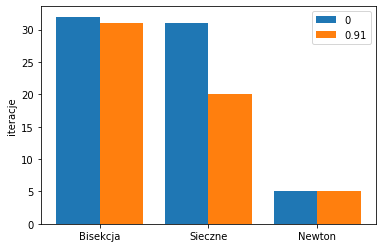

In [10]:
x0=np.zeros(3)
x1=np.zeros(3)

x,x0[0]=main.bisection(0.5,1.5,main.fun,10**(-10),100000)
x,x1[0]=main.bisection(-0.5,0.25,main.fun,10**(-10),100000)
x,x0[1]=main.secant(0.5,1.5,main.fun,10**(-10),100000)
x,x1[1]=main.secant(-0.5,0.25,main.fun,10**(-10),100000)
x,x0[2]=main.newton(main.fun,main.dfun,main.ddfun,0.5,1.5,10**(-10),100000)
x,x1[2]=main.newton(main.fun,main.dfun,main.ddfun,-0.5,0.25,10**(-10),100000)
labels = ['Bisekcja', 'Sieczne', 'Newton']
fig, b = plt.subplots()
x = np.arange(len(labels))
b.bar(x-0.2,x1,0.4,label='0')
b.bar(x+0.2,x0,0.4,label='0.91')
b.set_xticks(x)
b.set_xticklabels(labels)
plt.legend()
plt.ylabel('iteracje')

Dla obydwu przedziałów Newton bije resztą metod na głowę dochodząc daleko ponad zadaną dokładność w 6 iteracji. Jest przez to jednak ciężko zaobserwować w tej metodzie wpływ wyboru przedziału na iteracja potrzebne na wyznaczenie miejsca zerowego z zadaną tolerancją, co jest bardzo widoczne w przypadku metody siecznych i trochę dla bisekcji.
 Zatem jeśli tylko ma się dostęp do informacji o df i dff funckcji bez potrzeby ichbwyliczania jak w zadaniu, najlepiej jest użyć Newtona.
 Bisekcję i sieczną mając odpowiednio dobrany przedział, przy czym bisekcję w ostateczności.

376 ns ± 38.5 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
363 ns ± 16.6 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
375 ns ± 37.2 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
367 ns ± 17.6 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
384 ns ± 69.7 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
395 ns ± 3.21 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
362 ns ± 13 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
367 ns ± 22 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
418 ns ± 121 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
415 ns ± 109 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)


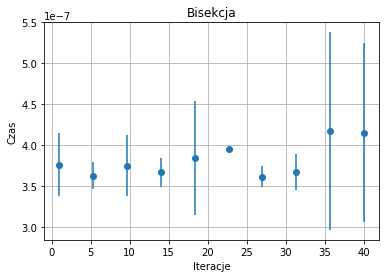

380 ns ± 46.5 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
406 ns ± 53.4 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
373 ns ± 16 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
452 ns ± 153 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
406 ns ± 8.08 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
389 ns ± 20 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
379 ns ± 40 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
373 ns ± 15.9 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
369 ns ± 6.42 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
370 ns ± 5.88 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)


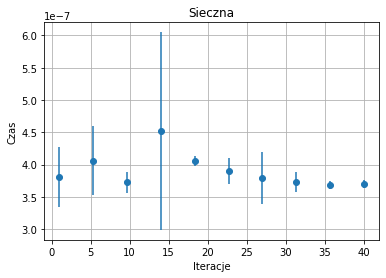

411 ns ± 19 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
414 ns ± 13.3 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
408 ns ± 15.4 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
430 ns ± 36 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
415 ns ± 12.9 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
427 ns ± 76.8 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
407 ns ± 15.9 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
403 ns ± 4.04 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
410 ns ± 10.8 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)
403 ns ± 3.62 ns per loop (mean ± std. dev. of 100 runs, 100 loops each)


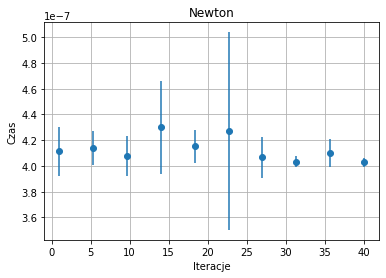

[Text(0, 0, '4'),
 Text(1, 0, '8'),
 Text(2, 0, '12'),
 Text(3, 0, '16'),
 Text(4, 0, '20'),
 Text(5, 0, '24'),
 Text(6, 0, '28'),
 Text(7, 0, '32'),
 Text(8, 0, '36'),
 Text(9, 0, '40')]

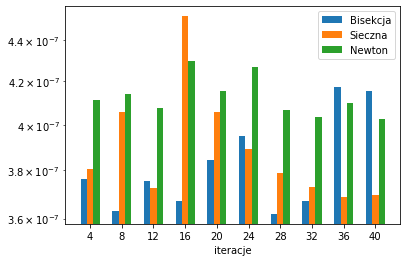

In [11]:
err=[]
t1=[]
x = np.linspace(1, 40, 10)
for i in x:
    avg_time = %timeit -r 100 -n 100 -o main.bisection(-0.5,0.25,main.fun,10**(-10),i)
    t1.append(avg_time.average)
    err.append(avg_time.stdev)
    
plt.errorbar(x, t1,yerr=err, marker="o", linestyle='None')
plt.ylabel("Czas")
plt.xlabel("Iteracje")
plt.title("Bisekcja")
plt.grid()
plt.show()

err=[]
t2=[]
for i in x:
    avg_time = %timeit -r 100 -n 100 -o main.secant(-0.5,0.25,main.fun,10**(-10),i)
    t2.append(avg_time.average)
    err.append(avg_time.stdev)
plt.errorbar(x, t2,yerr=err, marker="o", linestyle='None')
plt.ylabel("Czas")
plt.xlabel("Iteracje")
plt.title("Sieczna")
plt.grid()
plt.show()

err=[]
t3=[]
for i in x:
    avg_time = %timeit -r 100 -n 100 -o main.newton(main.fun,main.dfun,main.ddfun,-0.5,0.25,10**(-10),i)
    t3.append(avg_time.average)
    err.append(avg_time.stdev)
plt.errorbar(x, t3,yerr=err, marker="o", linestyle='None')
plt.ylabel("Czas")
plt.xlabel("Iteracje")
plt.title("Newton")
plt.grid()
plt.show()

l=0.2
labe=['4','8','12','16','20','24','28','32','36','40']
fig, c = plt.subplots()
xa = np.arange(len(x))
c.bar(xa-0.2,t1,l,label='Bisekcja')
c.bar(xa,t2,l,label='Sieczna')
c.bar(xa+0.2,t3,l,label='Newton')
plt.semilogy()
plt.legend()
plt.xlabel('iteracje')
c.set_xticks(xa)
c.set_xticklabels(labe)




Na przedziale [-0.5,0.25] Newton jest najbardziej jednostajny pod względem czasu wykonywania od iteracji, co uważam za powiązane z możliwością korzystania tylko z jednej zmiennej podczas pętli i sprawdzania za którą zmienną trzeba nowo wyliczoną, bliższą rozwiązaniu zamienić co było koniecznością w poprzednich, u których tłumaczyłoby to wachania czasu wykonywania gdy raz nową zmienna przechodziła pierwszego a raz następnego if'a (podejrzewam że dałoby się określić po skokach i spadkach w czasie wykonywania po której stronie miejsca zerowego wyznaczano większość nowych przybliżonych wartości).
Natomiast mimo to dłuższy średnio czas wykonywania się Newtona wiążę z koniecznością sprawdzania znaku df i ddf funckcji.

[Text(0, 0, '4'),
 Text(1, 0, '8'),
 Text(2, 0, '12'),
 Text(3, 0, '16'),
 Text(4, 0, '20'),
 Text(5, 0, '24'),
 Text(6, 0, '28'),
 Text(7, 0, '32'),
 Text(8, 0, '36'),
 Text(9, 0, '40')]

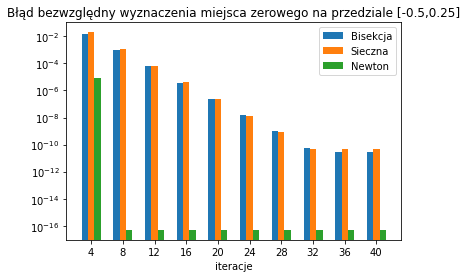

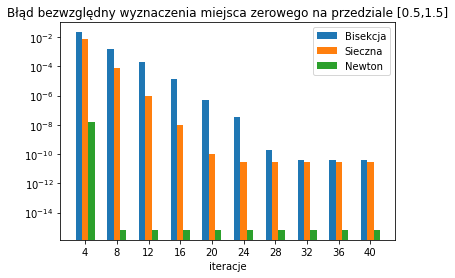

In [12]:
x = np.linspace(1, 40, 10)
dif1=[]
dif2=[]
dif3=[]
for i in range(10):
    s,it=main.bisection(-0.5,0.25,main.fun,10**(-10),4*(i+1))
    dif1.append(abs(s))
    s,it=main.secant(-0.5,0.25,main.fun,10**(-10),4*(i+1))
    dif2.append(abs(s))
    s,it=main.newton(main.fun,main.dfun,main.ddfun,-0.5,0.25,10**(-10),4*(i+1))
    dif3.append(abs(s))

    

l=0.2
labe=['4','8','12','16','20','24','28','32','36','40']
fig, d = plt.subplots()
xa = np.arange(len(x))
d.bar(xa-0.2,dif1,l,label='Bisekcja')
d.bar(xa,dif2,l,label='Sieczna')
d.bar(xa+0.2,dif3,l,label='Newton')
plt.semilogy()
plt.legend()
plt.xlabel('iteracje')
plt.title("Błąd bezwzględny wyznaczenia miejsca zerowego na przedziale [-0.5,0.25]")
d.set_xticks(xa)
d.set_xticklabels(labe)

x = np.linspace(1, 40, 10)
dif1=[]
dif2=[]
dif3=[]
for i in range(10):
    s,it=main.bisection(0.5,1.5,main.fun,10**(-10),4*(i+1))
    dif1.append(abs(s-f2[1]))
    s,it=main.secant(0.5,1.5,main.fun,10**(-10),4*(i+1))
    dif2.append(abs(s-f2[1]))
    s,it=main.newton(main.fun,main.dfun,main.ddfun,0.5,1.5,10**(-10),4*(i+1))
    dif3.append(abs(s-f2[1]))

    

fig, d = plt.subplots()
d.bar(xa-0.2,dif1,l,label='Bisekcja')
d.bar(xa,dif2,l,label='Sieczna')
d.bar(xa+0.2,dif3,l,label='Newton')
plt.semilogy()
plt.legend()
plt.xlabel('iteracje')
plt.title("Błąd bezwzględny wyznaczenia miejsca zerowego na przedziale [0.5,1.5]")
d.set_xticks(xa)
d.set_xticklabels(labe)

Jak widać już od 8 iteracji Newton zdecydowanie prowadzi, a w obu przypadach jest najdokładniejszy we wszystkich punktach pomiarowych. Dokładność po 8 iteracjach sięga zera maszynowego i jest tak duża w porównianiu do pozostałych metod na iterację że nawet czasowo już od 8 iteracji Newton staje się lepszą opcją (przynajmniej na tych przedziałach).
Po różnicy między metodami bijekcji i siecznych widać jak dla tej drugiej ogromny wpływ wpływ miał dobór przedziału, przy czym obydwa zaczynały robić niewielki postęp od ok 32 iteracji, utrzymując się na dokładności rzędu 10^(-10)-10^(-12).
 Za wyjątkiem pewnych wyjątkowych przypadków bądź gdyby Newton "zaciął się", zaczął robić w pewnym momencie bardzo małe postępy wybrałbym zawsze jego metodę.
